In [1]:
import MDAnalysis as mda
from MDAnalysis.analysis import hydrogenbonds as hbonds
import megane
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Loads just a .gro single-frame file and checks if there are positions and velocities
pdbfile = "confout.pdb"
xtcfile = "traj_whole_1ps.xtc"
viewer = megane.view_traj(pdbfile, xtc=xtcfile); viewer

In [3]:
# Loads the initial config
uframe = mda.Universe(pdbfile)
print(np.shape(uframe.atoms.positions))
print(uframe.trajectory.ts.has_positions)
print(uframe.trajectory.ts.has_velocities)

# # Extract some coordinates (and time)
u = mda.Universe(pdbfile,xtcfile)
SDterm = u.select_atoms('name SD')[0]; SD_position = []
ODterm = u.select_atoms('name OD')[0]; OD_position = []
time = []

for ts in u.trajectory:     # iterate through all frames
    SD_position.append(SDterm.position) # end-to-end vector fr
    OD_position.append(ODterm.position)
    time.append(u.trajectory.time)

(11524, 3)
True
False


/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/topology/PDBParser.py:372: UserWarning: Unknown element  found for some atoms. These have been given an empty element record. If needed they can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn(wmsg)
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


In [4]:
# Time in ps
time = np.array(time)/1e3; print ('time ...',np.shape(time))
Ntimes = len(time)

# Positions in nanometers
SD_position_x = np.array(SD_position)[:,0]/10
SD_position_y = np.array(SD_position)[:,1]/10
SD_position_z = np.array(SD_position)[:,2]/10
OD_position_x = np.array(OD_position)[:,0]/10
OD_position_y = np.array(OD_position)[:,1]/10
OD_position_z = np.array(OD_position)[:,2]/10

time ... (56,)


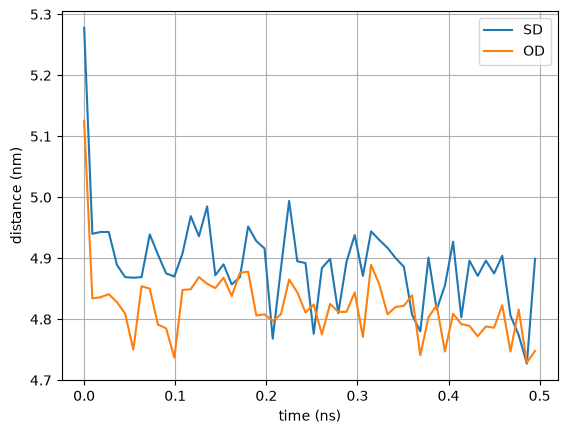

In [5]:
plt.figure()
plt.plot(time,SD_position_z,label='SD')
plt.plot(time,OD_position_z,label='OD')
plt.xlabel('time (ns)')
plt.ylabel('distance (nm)')
plt.legend()
plt.grid(True)

In [6]:
# # Turn this on if we want to look at the trajectory
# TOTview = nv.show_mdanalysis(u)
# TOTview.clear()
# TOTview.add_contact(hydrogen_bond=True) # This slows things down a lot
# TOTview.add_representation('licorice',selection='SOL',opacity=0.6)
# # TOTview.add_representation('surface',selection='SOL',opacity=0.8)
# TOTview.add_representation('ball+stick',selection='RNA')
# TOTview.add_representation('ball+stick',selection='NA',color='green',radius=.3)
# TOTview.add_representation('ball+stick',selection='1509SOL')
# TOTview.add_representation('ball+stick',selection='1510SOL')
# TOTview.add_representation('ball+stick',selection='1511SOL')
# TOTview.add_representation('ball+stick',selection='1512SOL')
# TOTview.add_representation('ball+stick',selection='1513SOL')
# TOTview.add_representation('ball+stick',selection='1514SOL')
# TOTview.add_representation('ball+stick',selection='1515SOL')
# TOTview.add_representation('ball+stick',selection='1516SOL')
# TOTview.add_representation('ball+stick',selection='1517SOL')

# # # These are H-bonded to O2P at the beginning of this trajectory
# # TOTview.add_representation('ball+stick',selection='2297SOL',color='blue')
# # TOTview.add_representation('ball+stick',selection='2747SOL',color='blue')
# # TOTview.add_representation('ball+stick',selection='2537SOL',color='blue')

# # # These are H-bonded to O2P at the end of this trajectory
# # TOTview.add_representation('ball+stick',selection='2831SOL',color='green')
# # TOTview.add_representation('ball+stick',selection='2784SOL',color='green')
# # TOTview.add_representation('ball+stick',selection='2406SOL',color='green')

# TOTview.camera='orthographic'
# TOTview.center()
# TOTview.add_unitcell()
# TOTview.control.rotate([0,1,0,0])
# TOTview

In [7]:
# # Extract some coordinates (and time)
# P_position = []
# O1P_position = []
# O2P_position = []
# NA_position = []
# N4_position = []
# O3Prime_position = []
# H3T_position = []
# pullforce = []
# pullx = []
# time = []
# for ts in u.trajectory:     # iterate through all frames
#     P_position.append(Pterm.position) # end-to-end vector fr
#     O1P_position.append(O1Pterm.position)
#     O2P_position.append(O2Pterm.position)
#     O3Prime_position.append(O3Primeterm.position)
#     H3T_position.append(H3Tterm.position)
# #     N4_position.append(N4term.position)
# #     if pulling:
# #         pullforce.append(u.trajectory.ts.aux['pull'])
# #         pullx.append(u.trajectory.ts.aux['pullx'])
#     time.append(u.trajectory.time)
# print(np.shape(P_position))
# print(np.shape(O3Prime_position))
# print(np.shape(H3T_position))
# print(np.shape(time))
# time = np.array(time)/1e3; print ('time ...',np.shape(time))
# Ntimes = len(time)

In [8]:
# # Making numpy arrays, in nanometers
# P_position_x = np.array(P_position)[:,0]/10
# P_position_y = np.array(P_position)[:,1]/10
# P_position_z = np.array(P_position)[:,2]/10
# O1P_position_x = np.array(O1P_position)[:,0]/10
# O1P_position_y = np.array(O1P_position)[:,1]/10
# O1P_position_z = np.array(O1P_position)[:,2]/10
# O2P_position_x = np.array(O2P_position)[:,0]/10
# O2P_position_y = np.array(O2P_position)[:,1]/10
# O2P_position_z = np.array(O2P_position)[:,2]/10
# O3Prime_position_x = np.array(O3Prime_position)[:,0]/10
# O3Prime_position_y = np.array(O3Prime_position)[:,1]/10
# O3Prime_position_z = np.array(O3Prime_position)[:,2]/10
# H3T_position_x = np.array(H3T_position)[:,0]/10
# H3T_position_y = np.array(H3T_position)[:,1]/10
# H3T_position_z = np.array(H3T_position)[:,2]/10

In [9]:
# difference_array = (np.array(O3Prime_position)-np.array(H3T_position))/10
# print(np.shape(difference_array))
# squared_array = difference_array**2
# print(np.shape(squared_array))
# distance_array = (np.sum(squared_array,axis=1))**.5
# print(np.shape(distance_array))

# plt.figure()
# plt.plot(time*1e3,distance_array*1e3)
# plt.xlabel('time (fs)')
# plt.ylabel('OH bond length (nm)')
# plt.grid(True)

In [10]:
# # Specify coordinates we want
# O2term = u.select_atoms("name O2'")[1]
# O3term = u.select_atoms("name O3'")[1]

# # Extract some coordinates (and time)
# O2_position = []
# O3_position = []

# for ts in u.trajectory:     # iterate through all frames
#     O2_position.append(O2term.position) # end-to-end vector fr
#     O3_position.append(O3term.position)

# # Making numpy arrays, in nanometers
# O2_position_x = np.array(O2_position)[:,0]/10
# O2_position_y = np.array(O2_position)[:,1]/10
# O2_position_z = np.array(O2_position)[:,2]/10
# O3_position_x = np.array(O3_position)[:,0]/10
# O3_position_y = np.array(O3_position)[:,1]/10
# O3_position_z = np.array(O3_position)[:,2]/10


In [11]:
# fontsize = 20
# figsize = (8,6)
# bottom = 0.15

# # z-coordinate graphics
# plt.figure(figsize=figsize)
# plt.plot(time,P_position_z,'k',label='P')
# plt.plot(time,O1P_position_z,'orange',label='O1P')
# plt.plot(time,O2P_position_z,'red',label='O2P')
# plt.grid(True)
# plt.xlabel('time (ns)',fontsize=fontsize)
# plt.ylabel('z (nm)',fontsize=fontsize)
# plt.legend(fontsize=fontsize)
# plt.xticks(fontsize=fontsize)
# plt.yticks(fontsize=fontsize)
# plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

# # more z-coordinate graphics
# plt.figure(figsize=figsize)
# istart=10
# plt.plot(time[istart:],P_position_z[istart:],'k',label='P')
# plt.plot(time[istart:],O1P_position_z[istart:],'orange',label='O1P')
# plt.plot(time[istart:],O2P_position_z[istart:],'red',label='O2P')
# plt.plot(time[istart:],O2_position_z[istart:],'blue',label="GO2'")
# plt.plot(time[istart:],O3_position_z[istart:],'green',label="GO3'")
# plt.grid(True)
# plt.xlabel('time (ns)',fontsize=fontsize)
# plt.ylabel('z (nm)',fontsize=fontsize)
# plt.legend(fontsize=fontsize)
# plt.xticks(fontsize=fontsize)
# plt.yticks(fontsize=fontsize)
# plt.subplots_adjust(bottom=bottom) # Adds a little space at the bottom so xlabel isn't cropped

# # plt.title(xtcfile)

# # # x-coordinate graphics
# # plt.figure(figsize=figsize)
# # plt.plot(time,P_position_x,'k',label='P')
# # plt.plot(time,O1P_position_x,'orange',label='O1P')
# # plt.plot(time,O2P_position_x,'red',label='O2P')
# # plt.grid(True)
# # plt.xlabel('time (ns)',fontsize=fontsize)
# # plt.ylabel('x (nm)',fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.xticks(fontsize=fontsize)
# # plt.yticks(fontsize=fontsize)
# # plt.subplots_adjust(bottom=bottom)

# # # y-coordinate graphics
# # plt.figure(figsize=figsize)
# # plt.plot(time,P_position_y,'k',label='P')
# # plt.plot(time,O1P_position_y,'orange',label='O1P')
# # plt.plot(time,O2P_position_y,'red',label='O2P')
# # plt.grid(True)
# # plt.xlabel('time (ns)',fontsize=fontsize)
# # plt.ylabel('y (nm)',fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.xticks(fontsize=fontsize)
# # plt.yticks(fontsize=fontsize)
# # plt.subplots_adjust(bottom=bottom)
# # plt.title(xtcfile)

# # # x-coordinate graphics
# # plt.figure(figsize=figsize)
# # plt.plot(time,P_position_x,'k',label='P')
# # plt.plot(time,O1P_position_x,'orange',label='O1P')
# # plt.plot(time,O2P_position_x,'red',label='O2P')
# # plt.grid(True)
# # plt.xlabel('time (ns)',fontsize=fontsize)
# # plt.ylabel('x (nm)',fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.xticks(fontsize=fontsize)
# # plt.yticks(fontsize=fontsize)
# # plt.subplots_adjust(bottom=bottom)

# # # y-coordinate graphics
# # plt.figure(figsize=figsize)
# # plt.plot(time,P_position_y,'k',label='P')
# # plt.plot(time,O1P_position_y,'orange',label='O1P')
# # plt.plot(time,O2P_position_y,'red',label='O2P')
# # plt.grid(True)
# # plt.xlabel('time (ns)',fontsize=fontsize)
# # plt.ylabel('y (nm)',fontsize=fontsize)
# # plt.legend(fontsize=fontsize)
# # plt.xticks(fontsize=fontsize)
# # plt.yticks(fontsize=fontsize)
# # plt.subplots_adjust(bottom=bottom)

In [12]:
# # 2-d histogram of solvent water (all z values)

# # Break out the oxygen atoms of the solvent
# OWterm_frame = uframe.select_atoms('name OW')
# print (np.shape(OWterm_frame.positions))

# # Extract coordinates
# OWx_frame = OWterm_frame.positions[:,0]/10; print(np.shape(OWx_frame)) # In nm
# OWy_frame = OWterm_frame.positions[:,1]/10; print(np.shape(OWy_frame))
# OWz_frame = OWterm_frame.positions[:,2]/10; print(np.shape(OWz_frame))

In [13]:
# # Phosphorus
# nlevels = 10; nx = 50; ny = 51
# MDC.heatmap_and_contours(P_position_x,P_position_y,'y','P',nx,ny,nlevels,'Oranges')

# # O1P
# nlevels = 10; nx = 50; ny = 51
# MDC.heatmap_and_contours(O1P_position_x,O1P_position_y,'r','O1P',nx,ny,nlevels,'Reds')

# # O2P
# nlevels = 10; nx = 50; ny = 51
# MDC.heatmap_and_contours(O2P_position_x,O2P_position_y,'r','O2P',nx,ny,nlevels,'Reds')

# # Ice
# nlevels = 10; nx = 100; ny = 101
# MDC.heatmap_and_contours(OWx_frame,OWy_frame,'b','ice',nx,ny,nlevels,'Blues')

# # O1P and ice
# nx = 100; ny = 101
# MDC.heatmap(OWx_frame,OWy_frame,'b','O1P and ice',nx,ny,'Blues')
# nlevels = 4; nx = 50; ny = 51
# MDC.and_contours(O1P_position_x,O1P_position_y,'r',nx,ny,nlevels)

# # O2P and ice
# nx = 100; ny = 101
# MDC.heatmap(OWx_frame,OWy_frame,'b','O2P and ice',nx,ny,'Blues')
# nlevels = 4; nx = 50; ny = 51
# MDC.and_contours(O2P_position_x,O2P_position_y,'r',nx,ny,nlevels)

In [14]:
# # Gets O1P autocorrelation function
# filename = 'hbac_O1P.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O1P_SOL = hbac_data[:,0]/1e3
# hbac_O1P_SOL = hbac_data[:,1]

# # Gets O2P autocorrelation function
# filename = 'hbac_O2P.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O2P_SOL = hbac_data[:,0]/1e3
# hbac_O2P_SOL = hbac_data[:,1]

# # Plots them together
# plt.figure()
# plt.plot(time_O1P_SOL,hbac_O1P_SOL,label='O1P')
# plt.plot(time_O2P_SOL,hbac_O2P_SOL,label='O2P')
# plt.grid(True)
# plt.xlabel('time (ns)')
# plt.ylabel('H-bond autocorrelation function')
# plt.legend()

# # filename = 'hbac_O2P.xvg'; print(filename)
# # hbac = mda.auxiliary.XVG.XVGReader(filename)
# # hbac_data = []
# # for auxstep in hbac:
# #     hbac_data.append(auxstep._data)
# # hbac_data = np.array(hbac_data)
# # print(np.shape(hbac_data))
# # plt.plot(hbac_data[:,0]/1e3,hbac_data[:,1],label='O2P',color='orange')
# # plt.grid(True)
# # plt.xlabel('time (ns)')
# # plt.ylabel('H-bond autocorrelation function')
# # plt.legend()

In [15]:
# # Gets O3' autocorrelation function
# filename = 'hbac_O3.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O3_SOL = hbac_data[:,0]/1e3
# hbac_O3_SOL = hbac_data[:,1]

# # Gets O2' autocorrelation function
# filename = 'hbac_O2.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O2_SOL = hbac_data[:,0]/1e3
# hbac_O2_SOL = hbac_data[:,1]

# # Gets O1P autocorrelation function
# filename = 'hbac_O1P.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O1P_SOL = hbac_data[:,0]/1e3
# hbac_O1P_SOL = hbac_data[:,1]

# # Gets O2P autocorrelation function
# filename = 'hbac_O2P.xvg'; print(filename)
# hbac = mda.auxiliary.XVG.XVGReader(filename)
# hbac_data = []
# for auxstep in hbac:
#     hbac_data.append(auxstep._data)
# hbac_data = np.array(hbac_data)
# print(np.shape(hbac_data))
# time_O2P_SOL = hbac_data[:,0]/1e3
# hbac_O2P_SOL = hbac_data[:,1]

# # Plots them together
# plt.figure()
# plt.plot(time_O2_SOL,hbac_O2_SOL,label='O2')
# plt.plot(time_O3_SOL,hbac_O3_SOL,label='O3')
# plt.plot(time_O1P_SOL,hbac_O1P_SOL,label='O1P')
# plt.plot(time_O2P_SOL,hbac_O2P_SOL,label='O2P')
# plt.grid(True)
# plt.xlabel('time (ns)')
# plt.ylabel('H-bond autocorrelation function')
# plt.legend()

In [16]:
# # Does a fit of autocorrelation functions to a*exp(-x/tau)+c

# # Define the fitting function
# def myexp(x, a, tau, c):
#     return a * np.exp(- x/tau) + c

# # We'll need scipy for this
# import scipy

# # Do the fitting (O1P and O2P)
# popt_O1P,pcov = scipy.optimize.curve_fit(myexp, time_O1P_SOL, hbac_O1P_SOL)
# print(popt_O1P)
# tau_O1P = np.round(popt_O1P[1],1); print(tau_O1P)
# popt_O2P,pcov = scipy.optimize.curve_fit(myexp, time_O2P_SOL, hbac_O2P_SOL)
# print(popt_O2P)
# tau_O2P = np.round(popt_O2P[1],1); print(tau_O2P)

# # Plot the results
# plt.figure()
# plt.plot(time_O1P_SOL, hbac_O1P_SOL, color='blue', marker='+', label="O1P w/τ="+str(tau_O1P))
# plt.plot(time_O1P_SOL, myexp(time_O1P_SOL, *popt_O1P), color='blue', label="Fitted Curve")
# plt.plot(time_O2P_SOL, hbac_O2P_SOL, color='orange', marker='+', label="O2P w/τ="+str(tau_O2P))
# plt.plot(time_O2P_SOL, myexp(time_O2P_SOL, *popt_O2P), color='orange', label="Fitted Curve")
# plt.legend()
# plt.grid(True)
# plt.xlabel('time (ns)')
# plt.ylabel('H-bond autocorrelation function')

In [17]:
# # select atoms of interest into AtomGroups
# H = u.select_atoms('name H')
# N = u.select_atoms('name N4')
# O = u.select_atoms('name SOL')
# # create analysis object
# hb_ac = hbonds.HydrogenBondAutoCorrel(u,
#             acceptors=O, hydrogens=H, donors=N,
#             bond_type='continuous',
#             sample_time=2.0, nsamples=1000, nruns=20)
# # call run to gather results
# hb_ac.run()
# # attempt to fit results to exponential equation
# hb_ac.solve()
# # grab results from inside object
# tau = hb_ac.solution['tau']
# time = hb_ac.solution['time']
# results = hb_ac.solution['results']
# estimate = hb_ac.solution['estimate']
# # plot to check!
# plt.plot(time, results, 'ro')
# plt.plot(time, estimate)
# plt.show()